In [1]:
# Setup cell — run this first
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification, make_blobs, make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("Import Successful")

Import Successful


**Support Vector Machines(SVM)**

Imagine you have two groups of people, red team and blue team, standing on a field you want to draw a line between them so the two groups are separated.

But there are infinitely many lines you could draw that separate them. Which one is best?

SVM Says: draw a line that is as far as possible from the both groups. Give the line the maximum breathing room, the wildest possible gap between the two sides.

The gap is called the margin.

The people standing closest to the line, the ones that matter most for where you draw it, are called support vectors.

Why it works this way?

The futher your boundary is from both groups, the more confident you canbe when a new person appears near the boundary/ A line crammed right next to one group is fragile, one step and someone crosses it wrongly.

Mathematically, SVM finds the line (or hyperplane in higher dimensions) that maximizes the amrgin between the two classes.

The decision boundary is:

w . x + b = 0

The two margin lines are:

w . x + b = +1 (positive side)

w . x + b = -1 (negative side)

The margine width = 2/||w||

Maximizing margin = minimizing ||w||, that is the optimization problem SVM solves.

Hyperplane:

the decision boundary, a line in 2D, a flat plane in 3D, a generalization in higher dimensions

Margin:

The gap between the boundary and the closest points on each side. Bigger=Better

Supprot Vector:

The data points sitting exactly on the margin edges. Remove all other points and the boundary doesn't change.

Hard Margin:

Only works when data is perfectly separable, no mistakes allowed

Soft Margin:

Allows some points to be on the wrong side. C controls how strict you are

C parameter:

High C=strict, thin margin, fits training data closely. Low C=relaxed, wide margin, more generalization

In [2]:
# ── Create perfectly separable data first ──
X, y = make_classification(n_samples=100, n_features=2,
                           n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, random_state=42) #Creates 2D data so we can visualize
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [3]:
scaler = StandardScaler() #SVM is distance-based unscaled features break it
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [4]:
# Train SVM with linear kernel
svm = SVC(kernel='linear', C=1.0) #Linear=straight boundary, c-1.0, balanced starting point
svm.fit(X_train_s, y_train)

print(f"✅ SVM Accuracy: {accuracy_score(y_test, svm.predict(X_test_s)):.4f}")
print(f"Number of support vectors: {svm.n_support_}")
print(f"(Class 0: {svm.n_support_[0]}, Class 1: {svm.n_support_[1]})") #n_support_=Count of supprot vecators per class

✅ SVM Accuracy: 1.0000
Number of support vectors: [2 2]
(Class 0: 2, Class 1: 2)


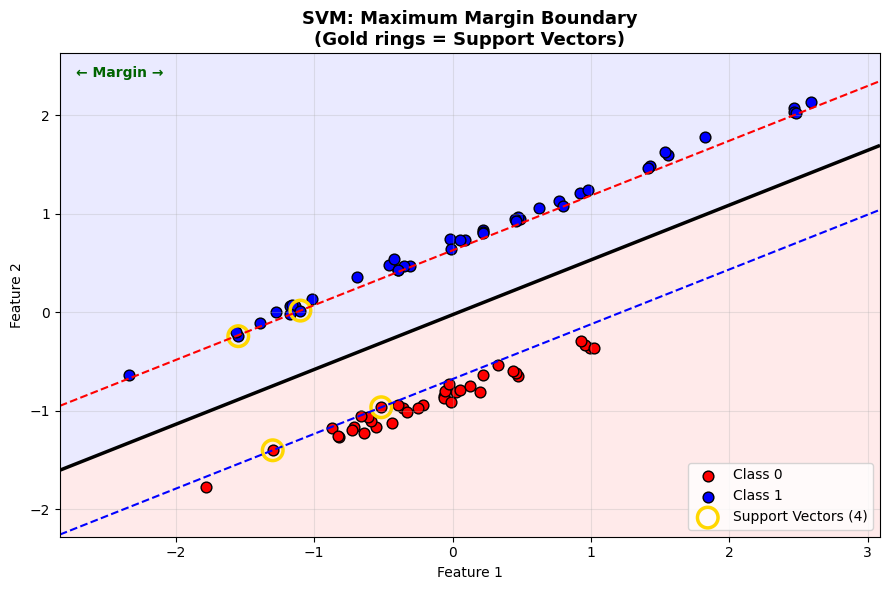

In [5]:
# ── Visualise the margin and support vectors ──
def plot_svm_boundary(model, X, y, title="SVM Decision Boundary"):
    fig, ax = plt.subplots(figsize=(9, 6))

    # Create grid to shade decision regions
    x_min, x_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    y_min, y_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                          np.linspace(y_min, y_max, 300))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]) #Returns distance of each point from boundary
    #Positive dist=one side, negative distance=other side
    Z = Z.reshape(xx.shape)

    # Shade background
    ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                colors=['#FFCCCC', '#CCCCFF'], alpha=0.4)

    # Draw the 3 lines: decision boundary + 2 margin lines
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], #draws the boundary (0) and both margin lines(-1,+1)
               linestyles=['--', '-', '--'],
               colors=['blue', 'black', 'red'],
               linewidths=[1.5, 2.5, 1.5])

    # Plot all points
    ax.scatter(X[y==0, 0], X[y==0, 1],
               color='red', s=60, edgecolors='k', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1],
               color='blue', s=60, edgecolors='k', label='Class 1')

    # Highlight support vectors with a ring
    ax.scatter(model.support_vectors_[:, 0],
               model.support_vectors_[:, 1],
               s=220, facecolors='none',
               edgecolors='gold', linewidths=2.5,
               label=f'Support Vectors ({len(model.support_vectors_)})') #support_vectors_=The actual points sitting on the margin edges

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")

    # Annotations
    ax.annotate("← Margin →", xy=(0, 0), xytext=(0.02, 0.95),
                xycoords='axes fraction', fontsize=10,
                color='darkgreen', fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_svm_boundary(svm, X_train_s, y_train,
                  "SVM: Maximum Margin Boundary\n"
                  "(Gold rings = Support Vectors)")

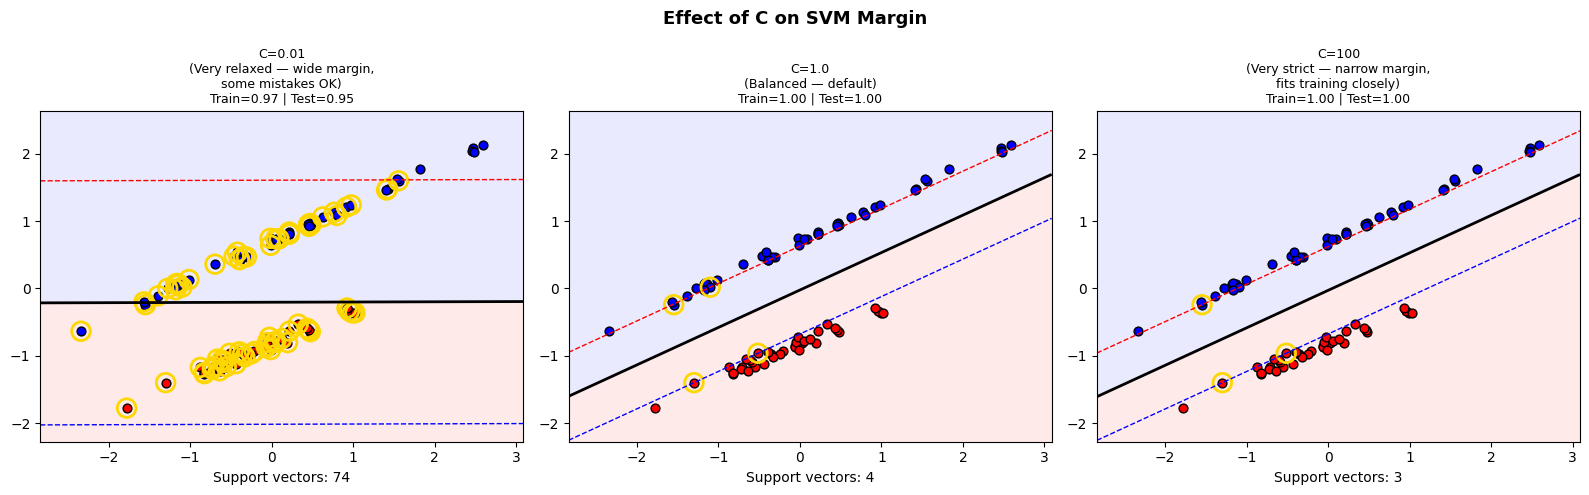

🔑 KEY RULE TO REMEMBER:
High C = trust the data, risk overfitting
Low C  = trust the margin, risk underfitting
Think of C as: 'How much do I care about misclassifying training points?'


In [7]:
# ── Show what C does ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
C_values = [0.01, 1.0, 100.0] #0.01: Wide margin, some points allowed inside → more robust
#100: Narrow margin, almost no mistakes → potentially overfit
descriptions = [
    "C=0.01\n(Very relaxed — wide margin,\nsome mistakes OK)",
    "C=1.0\n(Balanced — default)",
    "C=100\n(Very strict — narrow margin,\nfits training closely)"
]

for ax, C, desc in zip(axes, C_values, descriptions):
    model = SVC(kernel='linear', C=C)
    model.fit(X_train_s, y_train)

    x_min, x_max = X_train_s[:,0].min()-0.5, X_train_s[:,0].max()+0.5
    y_min, y_max = X_train_s[:,1].min()-0.5, X_train_s[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                          np.linspace(y_min, y_max, 200))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-999,0,999],
                colors=['#FFCCCC','#CCCCFF'], alpha=0.4)
    ax.contour(xx, yy, Z, levels=[-1,0,1],
               linestyles=['--','-','--'],
               colors=['blue','black','red'], linewidths=[1,2,1])
    ax.scatter(X_train_s[y_train==0,0], X_train_s[y_train==0,1],
               color='red', s=40, edgecolors='k')
    ax.scatter(X_train_s[y_train==1,0], X_train_s[y_train==1,1],
               color='blue', s=40, edgecolors='k')
    ax.scatter(model.support_vectors_[:,0],
               model.support_vectors_[:,1],
               s=180, facecolors='none', edgecolors='gold', linewidths=2)

    train_acc = accuracy_score(y_train, model.predict(X_train_s))
    test_acc  = accuracy_score(y_test,  model.predict(X_test_s))
    ax.set_title(f"{desc}\nTrain={train_acc:.2f} | Test={test_acc:.2f}",
                 fontsize=9)
    ax.set_xlabel(f"Support vectors: {len(model.support_vectors_)}")

plt.suptitle("Effect of C on SVM Margin",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔑 KEY RULE TO REMEMBER:")
print("High C = trust the data, risk overfitting")
print("Low C  = trust the margin, risk underfitting")
print("Think of C as: 'How much do I care about misclassifying training points?'")

**The Kernel Trick**

what if your data cannot be separated by a straight line? Imagine red and blue points arranged in concentric circles, no line can separate them.

The kernel trick says: Instaed of drawing a curved line in 2D, lift the data into higher dimension where a straight line CAN separate them.

Think of it like this: scatter red and blue marbles on table(2D). You can't separate them with a ruler. But if you flip the table and the marbles fly into the air(3D), syddenly you can slide a flat sheet of paper between them.

The kernel trick does this matematically, without actually computing the high dimensional coordinates, which would be expensive. It only computesthe distances between points in that space using a shortcut formula called a kernel function.

Core Logic:

The kernel function K(xi, xj) computes the dt product between two points as if they were in a higher dimensional space, without ever going there.

Most common kernels:
* **Linear:** K(xi,xj)=xi.xj, no transformation, same space.

* **RBF(Gaussian):** K(xi.xj)=e^−γ∣∣xi​−xj​∣∣2, infinite dimensions.

* **Polynomial:** K(xi.xj)=(xi.xj+c)^d, polynomial feature space

RBF kernel can separate any dataset if gamma is tuned right, but too much power=overfitting.

Kernel:

A function that measures similarity between two points (secretly in higer-dimensional space)

RBF(Radial Basis Function):

Most popular kernel. Points close together=high similarity. Like a bell curve centered at each point.

Gamma: Controls how far the influence of a single point reaches. High gamma=points only influence their close neighbours(complex boundary). Low gamma=smooth, wide influence.

Feature map:

The actual high-dimensional transformation. Kernel computes its result without computing it explicitly.

In [8]:
# ── The problem: circles that NO line can separate ──
X_circ, y_circ = make_circles(n_samples=300,
                               noise=0.1, factor=0.4,
                               random_state=42) #creates inner/outer ring pattern, impossible for linear SVM
scaler2 = StandardScaler()
X_circ_s = scaler2.fit_transform(X_circ)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_circ_s, y_circ, test_size=0.2, random_state=42)

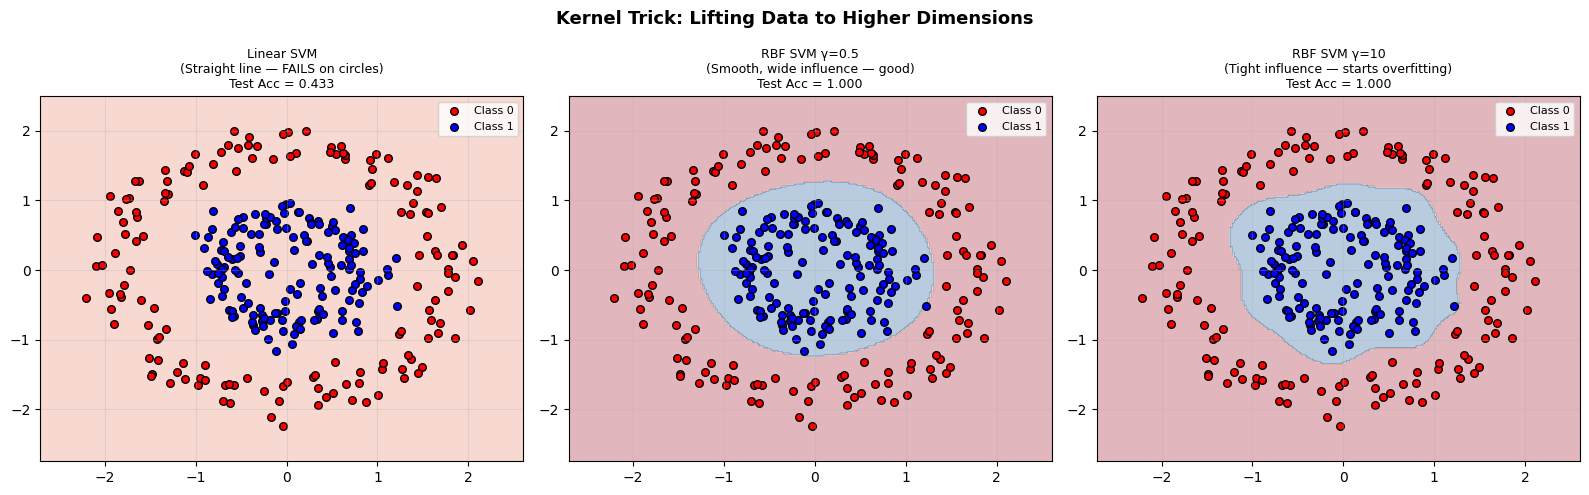


THE TAKEAWAY:
Linear kernel: straight line only — fails on complex shapes
RBF kernel:    can draw ANY curved boundary
γ too high:    boundary wraps tightly around each point → overfit
γ too low:     boundary too smooth → underfit

Rule of thumb: always try RBF first, tune C and gamma with cross-validation


In [10]:
# Compare: Linear (fails) vs RBF (succeeds)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
kernels = [
    ('linear', 1.0, 'auto',
     'Linear SVM\n(Straight line — FAILS on circles)'), #only draws straight lines, fails completely on circles
    ('rbf', 1.0, 0.5,
     'RBF SVM γ=0.5\n(Smooth, wide influence — good)'), #uses gaussian similarity, can form curved, circular boundaries
    ('rbf', 1.0, 10.0,
     'RBF SVM γ=10\n(Tight influence — starts overfitting)'), #gamma=0.5 →  Each point influences a wide area → smooth boundary
      #gamma=10 →  Each point only influences nearby points → wiggly, overfitting

]
# the decision region plot shows:
# red region: model predicts class 0
# blue region: model predicts class 1
# The boundary between them=decision boundary
# RBF gamma=0.5 learns the circular pattern almost perfectly
for ax, (kernel, C, gamma, title) in zip(axes, kernels):
    kwargs = {'kernel': kernel, 'C': C}
    if kernel == 'rbf':
        kwargs['gamma'] = gamma
    model = SVC(**kwargs)
    model.fit(X_tr_c, y_tr_c)

    x_min, x_max = X_circ_s[:,0].min()-0.5, X_circ_s[:,0].max()+0.5
    y_min2, y_max2 = X_circ_s[:,1].min()-0.5, X_circ_s[:,1].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250),
                          np.linspace(y_min2, y_max2, 250))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_circ_s[y_circ==0,0], X_circ_s[y_circ==0,1],
               color='red', s=30, edgecolors='k', label='Class 0')
    ax.scatter(X_circ_s[y_circ==1,0], X_circ_s[y_circ==1,1],
               color='blue', s=30, edgecolors='k', label='Class 1')

    test_acc = accuracy_score(y_te_c, model.predict(X_te_c))
    ax.set_title(f"{title}\nTest Acc = {test_acc:.3f}", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Kernel Trick: Lifting Data to Higher Dimensions",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTHE TAKEAWAY:")
print("Linear kernel: straight line only — fails on complex shapes")
print("RBF kernel:    can draw ANY curved boundary")
print("γ too high:    boundary wraps tightly around each point → overfit")
print("γ too low:     boundary too smooth → underfit")
print("\nRule of thumb: always try RBF first, tune C and gamma with cross-validation")


C: margin hard/soft
Gamma: boundary wrap(tight/smooth)

**K-means Clustering**

You have 1000 customers and no labels. You want to group them into segments, maybe "high spenders", "occasional buyers", "window shoppers." Nobody told you the groups, you have to discover them yourself. this is unsupervised learning.

K-means says: I will find K groups by repeatedly doing two things:

1. Assign every point to its nearest group centre.

2. Move each group centre to the average of its assigned points.

..until nothing changes

Think of it like organizing peopel at a party. Evryone stands near who they feel closest to, then the "leader" of each group moves to the center of their cluster. People re-decide who to stand near. Leaders move again. Repeat until everyone is happy.

Core logic:

The E-M steps:

K-means is actually a special case of the Expectation-Maximaization (EM) algorithm,

* E-step(Expectation): Assign each point to the nearest centroid.

Distance- Euclidean d = d=sqrt(∑(xi​−μi​)2)

*M-step(Maximization): Move each centroid to the mean of its assigned points.

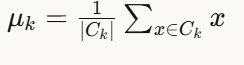

Why does it converge? Each step can only decrease or maintain the total within-cluster variance, it can never increase it. So it always reaches a stable point (not necessarily the best one).

Centroid:

the center point of a cluster, the average of all points in that group.

Inertia:

 Total distance of all points from their centriod. Lower=tighter clusters.

K:

Number of clusters you choose in advance. This is the main weakness of K-means

Elbow Method:

Plot inertial vs K. Where teh curve bends (the elbow) is the best K.

K-means++:

A smarter way to initialize centriods, spread them out, avoids bad start.

Silhouette Score:

Measures how well-separated clusters are. Range: -1 to 1. Higher=better





Running K-Means (k=4):
  Converged at iteration 7


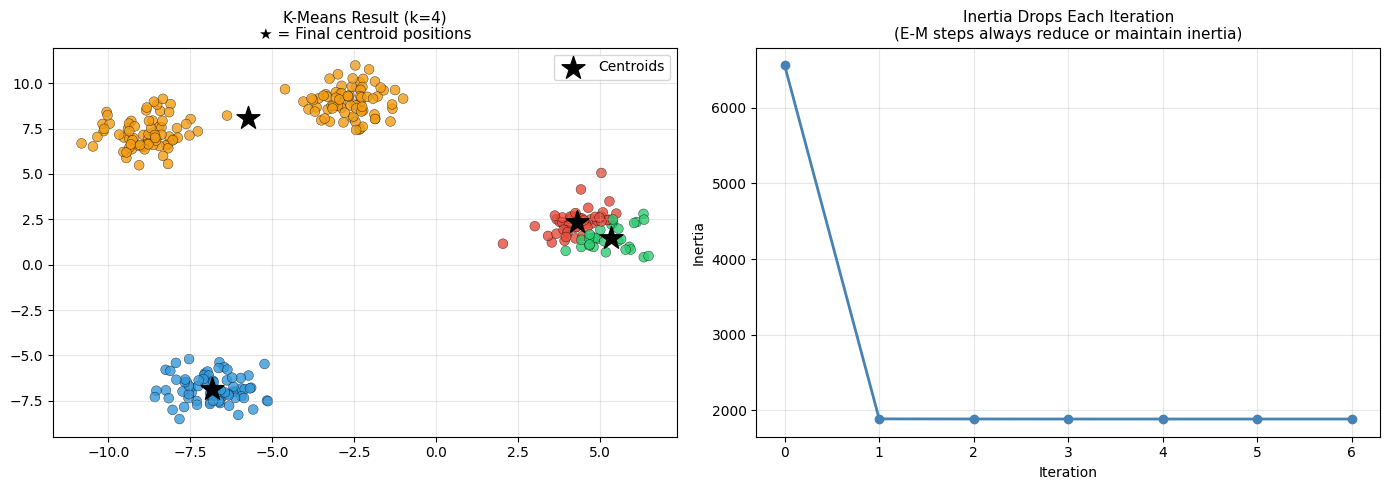

In [11]:
# ── STEP 1: Build K-Means from scratch ──
class KMeansFromScratch:
    """
    K-Means in plain steps.
    Watch each iteration and see the centroids move.
    """

    #store k, max iterations
    def __init__(self, k=3, max_iterations=100,
                 random_state=42):
        self.k = k
        self.max_iter = max_iterations
        self.centroids = None
        self.labels = None
        self.inertia_history = []
        np.random.seed(random_state)

    def fit(self, X):
        n_samples, n_features = X.shape

        # ── INITIALISE: pick K random points as starting centroids ──
        # (This is the simple version. K-Means++ does this smarter.)
        idx = np.random.choice(n_samples, self.k, replace=False) #pick k random starting centroids
        self.centroids = X[idx].copy()

        for iteration in range(self.max_iter):
            old_centroids = self.centroids.copy()

            # ── E-STEP: Assign each point to nearest centroid ──
            # distances shape: (n_samples, k)
            distances = np.array([ #for each centroid, compute distance to every point
                np.sqrt(np.sum((X - centroid)**2, axis=1))
                for centroid in self.centroids
            ]).T
            self.labels = np.argmin(distances, axis=1) #each point joins nearest centroid's cluster

            # ── M-STEP: Move each centroid to its cluster's mean ──
            for cluster_id in range(self.k):
                mask = self.labels == cluster_id
                if mask.sum() > 0:   # Avoid empty cluster
                    self.centroids[cluster_id] = X[mask].mean(axis=0) #new centroid=avg position of all cluster members

            # Track inertia (total within-cluster distance)
            inertia = sum(
                np.sum((X[self.labels==k] - self.centroids[k])**2)
                for k in range(self.k)
            )
            self.inertia_history.append(inertia) #record total "tightness", always decreases

            # ── CONVERGENCE CHECK ──
            shift = np.sqrt(
                np.sum((self.centroids - old_centroids)**2))
            if shift < 1e-6: #if centroids barely moved, we have converged
                print(f"  Converged at iteration {iteration+1}")
                break

        return self

    def predict(self, X):
        distances = np.array([
            np.sqrt(np.sum((X - c)**2, axis=1))
            for c in self.centroids
        ]).T
        return np.argmin(distances, axis=1)

# ── Generate nice cluster data ──
X_clusters, y_true = make_blobs(
    n_samples=300, centers=4, cluster_std=0.8,
    random_state=42)

# Run our from-scratch K-Means
print("Running K-Means (k=4):")
km = KMeansFromScratch(k=4, random_state=42)
km.fit(X_clusters)

# ── Visualise the clustering result ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
color_labels = [colors[l] for l in km.labels]

# Left: final clustering
ax = axes[0]
ax.scatter(X_clusters[:, 0], X_clusters[:, 1],
           c=color_labels, s=50, edgecolors='k', linewidth=0.3,
           alpha=0.8)
ax.scatter(km.centroids[:, 0], km.centroids[:, 1],
           s=300, c='black', marker='*',
           zorder=5, label='Centroids')
ax.set_title("K-Means Result (k=4)\n"
             "★ = Final centroid positions", fontsize=11)
ax.legend(); ax.grid(alpha=0.3)

# Right: inertia over iterations
ax2 = axes[1]
ax2.plot(km.inertia_history, 'o-', color='steelblue',
         linewidth=2, markersize=6)
ax2.set_xlabel("Iteration"); ax2.set_ylabel("Inertia")
ax2.set_title("Inertia Drops Each Iteration\n"
              "(E-M steps always reduce or maintain inertia)", fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


 Finding the Best K with the Elbow Method:
  K=2: Inertia=9211.2, Silhouette=0.6030
  K=3: Inertia=1919.4, Silhouette=0.7783
  K=4: Inertia=362.5, Silhouette=0.8335
  K=5: Inertia=329.3, Silhouette=0.6976
  K=6: Inertia=294.6, Silhouette=0.5882
  K=7: Inertia=261.6, Silhouette=0.4487
  K=8: Inertia=232.0, Silhouette=0.3322
  K=9: Inertia=209.1, Silhouette=0.3439
  K=10: Inertia=188.7, Silhouette=0.3588


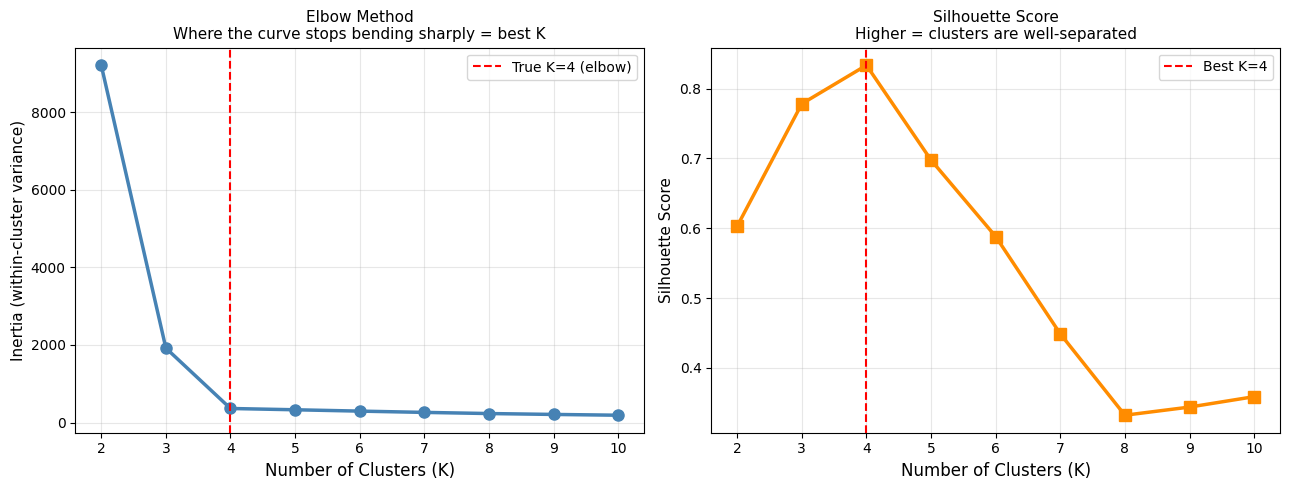


 ELBOW RULE: Look for where adding more K gives diminishing return
 SILHOUETTE: Use this to CONFIRM the elbow — both should agree


In [12]:
# ── STEP 2: The Elbow Method — how to choose K ──
print("\n Finding the Best K with the Elbow Method:")
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    from sklearn.cluster import KMeans as SKLearnKMeans
    km_sk = SKLearnKMeans(n_clusters=k, random_state=42,
                          n_init=10, init='k-means++')
    km_sk.fit(X_clusters)
    inertias.append(km_sk.inertia_)
    sil = silhouette_score(X_clusters, km_sk.labels_)
    silhouettes.append(sil)
    print(f"  K={k}: Inertia={km_sk.inertia_:.1f}, "
          f"Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
#high K->low intertia alwyas (more group=tighter)
#but after true K, adding more barely helps->"elbow"
axes[0].plot(K_range, inertias, 'o-',
             color='steelblue', linewidth=2.5, markersize=8)
axes[0].axvline(4, color='red', linestyle='--',
                label='True K=4 (elbow)')
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("Inertia (within-cluster variance)", fontsize=11)
axes[0].set_title("Elbow Method\n"
                  "Where the curve stops bending sharply = best K",
                  fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)

# Silhouette scores
#+1.0=point is perfectly in its own cluster, far from other
#0.0=point is on the boundary between two clusters
#-1.0=point is probably in the wrong cluster
axes[1].plot(K_range, silhouettes, 's-',
             color='darkorange', linewidth=2.5, markersize=8)
axes[1].axvline(K_range[np.argmax(silhouettes)],
                color='red', linestyle='--',
                label=f'Best K={K_range[np.argmax(silhouettes)]}')
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=11)
axes[1].set_title("Silhouette Score\n"
                  "Higher = clusters are well-separated", fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n ELBOW RULE: Look for where adding more K gives diminishing return")
print(" SILHOUETTE: Use this to CONFIRM the elbow — both should agree")


**DBSCAN**

K-means has a serious weakness: you must tell it how many groups to find, and it always forces every point into a group, even outliers and noise.

DBSCAN fixes both problems.

The analogy, a city and its suburbs: Imagine you are looking at a map with dots representing people's homes. A city is a dense cluster of homes close together. The countryside has scattered homes. DBSCAN finds the cities automatically, and labels the scattered homes as 'noise', without you telling it how many cities to look for.

DBSCAN groups points based on density, ow many points are within small radius of each point.

Core logic:

DBSCAN classifies every point as one of three types:

* Core point: Has at least min_sample neighbors with in radius epsilon.
* Border point: Not a core point, but is a neighbor of core point
* Noise point: neither core nor border, an outlie, labelled -1.

Then it grows clusters by connecting core points that are within epsilon of each other.

Epsilon:

The radius to look for neighbors. Think of it as "how close counts as close?"

min_sample:

min neighbors needed to be a core point. Think: "how dense is a real cluster?"

Core Point:

A point dense enough to start a cluster.

Border point:

On the edge of a cluster, too sparse to be core, but belongs to one

Noise(-1):

An outlier, doesn't belong to any cluster.

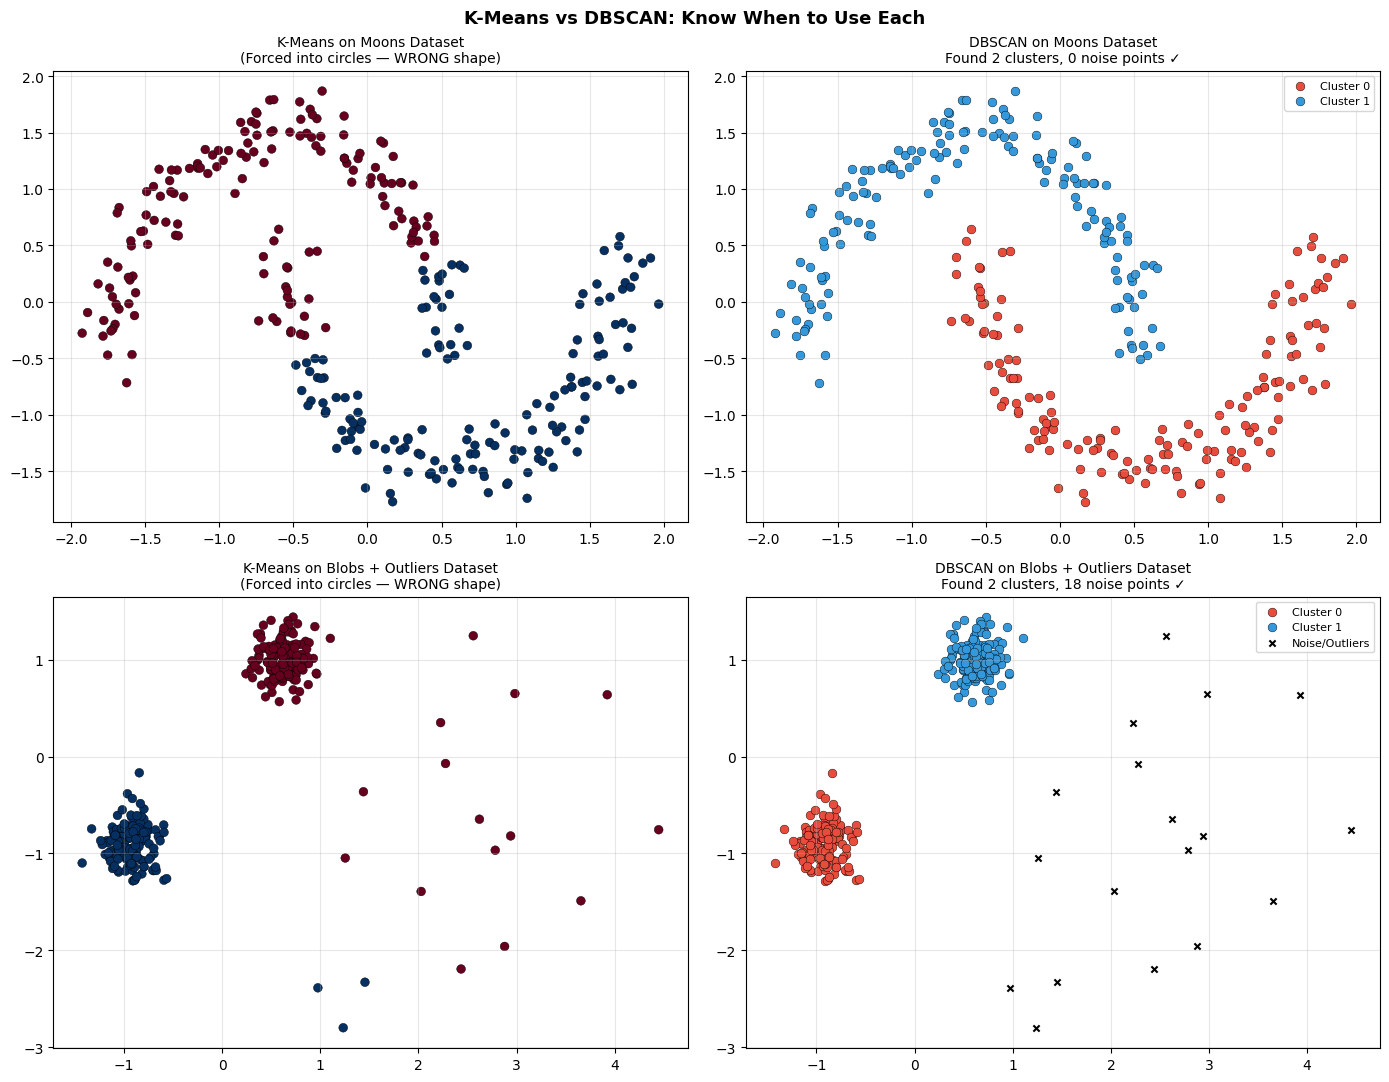


 WHEN TO USE WHICH:
K-Means:  Roughly circular clusters, known K, no outliers
DBSCAN:   Arbitrary shapes, unknown K, has outliers/noise
          Also great for anomaly detection (noise = anomaly!)


In [13]:
# ── Show where K-Means FAILS and DBSCAN SUCCEEDS ──
from sklearn.datasets import make_moons

# Dataset 1: Moons (crescent shapes — K-Means cannot handle)
X_moons, y_moons = make_moons(n_samples=300, noise=0.08,
                               random_state=42)
# Dataset 2: Blobs with an outlier cluster
X_blobs, y_blobs = make_blobs(n_samples=[150, 150, 20],
                               centers=[[0,0],[5,5],[10,0]],
                               cluster_std=[0.5, 0.5, 3.0],
                               random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

datasets = [
    (X_moons, "Moons Dataset"),
    (X_blobs, "Blobs + Outliers Dataset")
]

for row, (X_data, dataset_name) in enumerate(datasets):
    X_sc = StandardScaler().fit_transform(X_data)

    # K-Means attempt
    km_comp = KMeans(n_clusters=2, random_state=42, n_init=10)
    km_labels = km_comp.fit_predict(X_sc)

    ax = axes[row][0]
    scatter = ax.scatter(X_sc[:,0], X_sc[:,1],
                         c=km_labels, cmap='RdBu',
                         s=40, edgecolors='k', linewidth=0.3)
    ax.set_title(f"K-Means on {dataset_name}\n"
                 f"(Forced into circles — WRONG shape)",
                 fontsize=10)
    ax.grid(alpha=0.3)

    # DBSCAN attempt
    db = DBSCAN(eps=0.3, min_samples=5) #eps=0.3, A point's 'neighborhood radius' too small->everything is noise, too large->everything is one cluster
    #min_sample=5, need 5+ neighbors to be a core point
    #higher=more strict=smaller, denser cluster
    db_labels = db.fit_predict(X_sc)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise    = (db_labels == -1).sum() #these are the noise/outlier points (labelled -1), this is how dbscan does anomaly detection for free

    ax2 = axes[row][1]
    unique_labels = set(db_labels)
    palette = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
    for label in unique_labels:
        mask = db_labels == label
        if label == -1:
            ax2.scatter(X_sc[mask,0], X_sc[mask,1],
                        c='black', s=20, marker='x',
                        label='Noise/Outliers', zorder=3)
        else:
            ax2.scatter(X_sc[mask,0], X_sc[mask,1],
                        c=palette[label % len(palette)],
                        s=40, edgecolors='k', linewidth=0.3,
                        label=f'Cluster {label}')

    ax2.set_title(f"DBSCAN on {dataset_name}\n"
                  f"Found {n_clusters} clusters, "
                  f"{n_noise} noise points ✓",
                  fontsize=10)
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.suptitle("K-Means vs DBSCAN: Know When to Use Each",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n WHEN TO USE WHICH:")
print("K-Means:  Roughly circular clusters, known K, no outliers")
print("DBSCAN:   Arbitrary shapes, unknown K, has outliers/noise")
print("          Also great for anomaly detection (noise = anomaly!)")


K-Means on moons → draws a straight boundary between crescents → wrong
DBSCAN on moons  → follows the density along each crescent → correct

The x markers in black = noise points DBSCAN refused to assign to any cluster
This is USEFUL — they are likely outliers or anomalies in real data

**Pricipal Componenet Analysis (PCA)**

Imagine you are studying students and you ahve 20 different test scores for each student. That's 20 dimensions of information. but many scres are correlated, students who score high in Math tend to score high in physics. so you sont really have 20 independent pieces of information.

PCA finds the hidden, compressed summary of your data.

It says: these 20 scores can be summarized as mostly 2-3 underlying patterns (like 'science ability' and language ability). let them find those patterns and project eberyone onto them.

The result: you go from 20 numbers per student to 2-3 numbers, losing as little info as possible.

Core logic:

PCA finds the directions in your data where the covariance is highest, the directions where data spreds out the most. These directions are called principle componenets.

Mathematically, PCA finds these directions by computing the eigenvectors of the covariance matrix. The eigenvector with the largest eigenvalue=the direction of maximum variance=PC1.

Two equivalent ways to understand it:

* Maximize variance: find the axis along which data varies the most

* Minimise reconstruction error: find the projection that loses the least info.

Both lead to the same answer, the eigenvectors

Principle Component:

A new axis direction that captures maximum variance. PC1 captures the most, PC2 the second most , etc.

Explained Variance Ratio:

What fraction of total information each PC captures. PC1  + PC2 might explain 85% of all variance

Covariance matrix:

Measures how features vary together. PCA's core input

EigenVector:

the direction of a principle component.

Eigenvalue:

How much variance that component captures

Scree Plot:

Bar chart of explained variance per component, helps decide how many PCs to keep.

PCA: 30 features → 2 principal components
PC1 explains: 44.3% of variance
PC2 explains: 19.0% of variance
Total:        63.2% of variance preserved


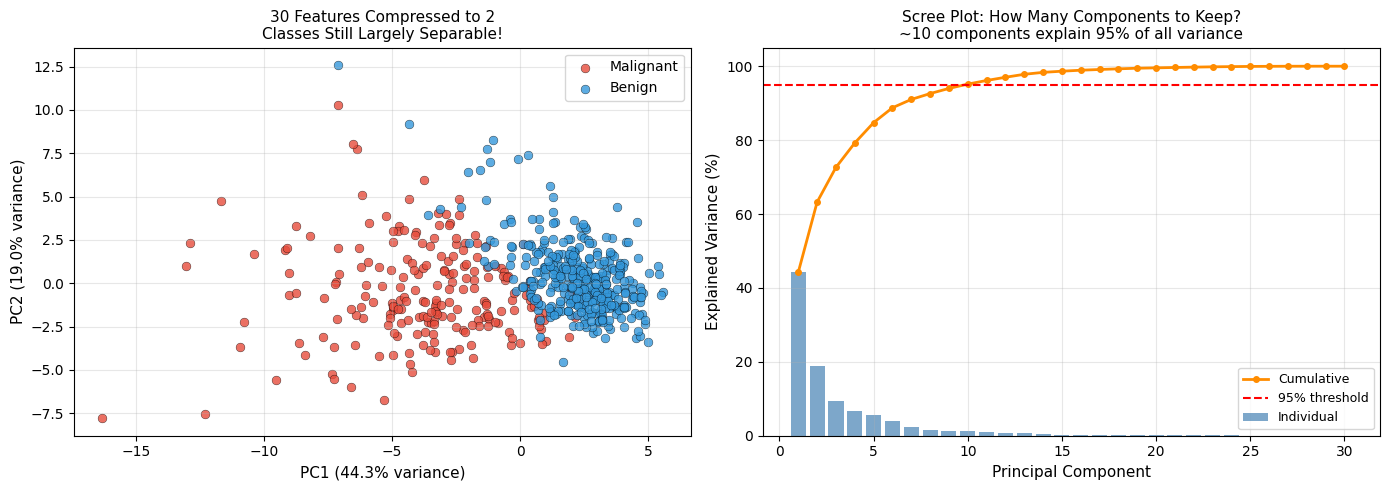

In [15]:
# ── PCA from scratch using only NumPy ──
class PCAFromScratch:
    """
    PCA in 4 crystal-clear steps.
    All we need is NumPy and linear algebra.
    """
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components = None          # eigenvectors (directions)
        self.explained_variance = None  # eigenvalues (importance)
        self.explained_variance_ratio_ = None
        self.mean = None

    def fit(self, X):
        # ── STEP 1: Centre the data (subtract mean) ──
        # PCA must be done on centred data, otherwise the first
        # component just points toward the mean, not variance
        self.mean = X.mean(axis=0)
        X_centred = X - self.mean

        # ── STEP 2: Compute the covariance matrix ──
        # Covariance matrix tells us how features vary together
        # Shape: (n_features, n_features)
        #Diagonal: variance of each feature
        #Off-diagonal: Correlation between features
        n = X.shape[0]
        cov_matrix = (X_centred.T @ X_centred) / (n - 1)

        # ── STEP 3: Find eigenvectors and eigenvalues ──
        # Eigenvectors = directions of maximum variance(PC) the new axis directions
        # Eigenvalues = how much variance each direction captures
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort by eigenvalue — largest first
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues  = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Keep only the top n_components
        self.components = eigenvectors[:, :self.n_components].T
        self.explained_variance = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = (
            self.explained_variance / eigenvalues.sum())

        return self

    def transform(self, X):
        # ── STEP 4: Project data onto principal components ──
        # Each data point becomes its coordinates in the new PC space
        X_centred = X - self.mean
        return X_centred @ self.components.T #coordinates of each point in PC space

    def fit_transform(self, X):
        return self.fit(X).transform(X)

# ── Apply to breast cancer dataset (30 features → 2) ──
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

# Scale first — PCA is sensitive to feature scales
scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

# Apply our from-scratch PCA
pca_scratch = PCAFromScratch(n_components=2)
X_bc_2d = pca_scratch.fit_transform(X_bc_scaled)

print("PCA: 30 features → 2 principal components")
print(f"PC1 explains: {pca_scratch.explained_variance_ratio_[0]:.1%} of variance")
print(f"PC2 explains: {pca_scratch.explained_variance_ratio_[1]:.1%} of variance")
print(f"Total:        "
      f"{pca_scratch.explained_variance_ratio_.sum():.1%} of variance preserved")

# Visualise the 2D projection
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, name, color in [(0,'Malignant','#E74C3C'),
                             (1,'Benign','#3498DB')]:
    mask = y_bc == label
    ax.scatter(X_bc_2d[mask,0], X_bc_2d[mask,1],
               c=color, s=40, edgecolors='k',
               linewidth=0.3, alpha=0.8, label=name)
ax.set_xlabel(f"PC1 ({pca_scratch.explained_variance_ratio_[0]:.1%} variance)",
              fontsize=11)
ax.set_ylabel(f"PC2 ({pca_scratch.explained_variance_ratio_[1]:.1%} variance)",
              fontsize=11)
ax.set_title("30 Features Compressed to 2\n"
             "Classes Still Largely Separable!", fontsize=11)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Scree plot — how many components do we need?
# it shows first few PCs capture most variance
# keep components until you reach 95% cumulative variance
pca_full = PCAFromScratch(n_components=30)
pca_full.fit(X_bc_scaled)

# Extend to all components with sklearn for full scree
from sklearn.decomposition import PCA as SKPCA
pca_all = SKPCA(n_components=30)
pca_all.fit(X_bc_scaled)
ev_ratios = pca_all.explained_variance_ratio_

ax2 = axes[1]
cumulative = np.cumsum(ev_ratios)
ax2.bar(range(1,31), ev_ratios*100,
        color='steelblue', alpha=0.7, label='Individual')
ax2.plot(range(1,31), cumulative*100,
         'o-', color='darkorange', linewidth=2,
         markersize=4, label='Cumulative')
ax2.axhline(95, color='red', linestyle='--',
            label='95% threshold')
ax2.set_xlabel("Principal Component", fontsize=11)
ax2.set_ylabel("Explained Variance (%)", fontsize=11)
ax2.set_title("Scree Plot: How Many Components to Keep?\n"
              f"~10 components explain 95% of all variance",
              fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

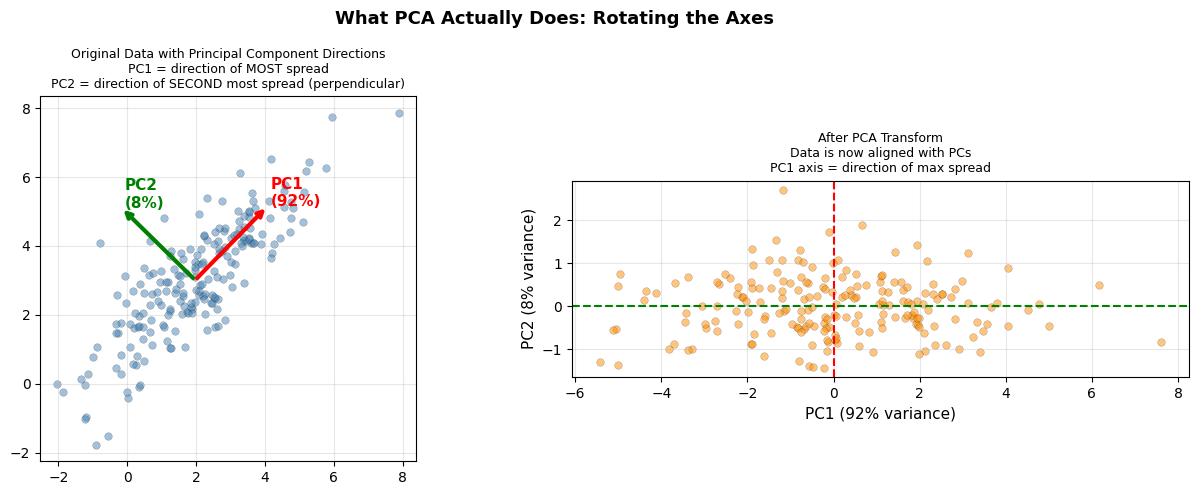


 THE ONE THING TO REMEMBER ABOUT PCA:
PCA doesn't remove features. It ROTATES the coordinate system
so that the new axes (PCs) align with the directions of
maximum variance in your data.
Then you DROP the low-variance directions — keeping the useful part.


In [16]:
# ── The beautiful part: visualise what PCA actually does ──
# Show the original 2D data with the principal component arrows

# Use a simple 2D dataset to make the directions visible
np.random.seed(42)
mean_vec = [2, 3]
cov_mat  = [[3, 2.5], [2.5, 3]]
X_demo   = np.random.multivariate_normal(mean_vec, cov_mat, 200)

pca_demo  = PCAFromScratch(n_components=2)
pca_demo.fit(X_demo)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Original space with PC arrows
ax = axes[0]
ax.scatter(X_demo[:,0], X_demo[:,1],
           alpha=0.5, s=30, color='steelblue', edgecolors='k',
           linewidth=0.2)

# Draw PC arrows from the mean
scale = 3
for i, (pc, var, color) in enumerate(zip(
    pca_demo.components,
    pca_demo.explained_variance,
    ['red', 'green']
)):
    ax.annotate('', xy=(pca_demo.mean[0] + scale*pc[0],
                         pca_demo.mean[1] + scale*pc[1]),
                xytext=(pca_demo.mean[0], pca_demo.mean[1]),
                arrowprops=dict(arrowstyle='->', color=color,
                                lw=3))
    ax.text(pca_demo.mean[0] + scale*pc[0] + 0.1,
            pca_demo.mean[1] + scale*pc[1],
            f'PC{i+1}\n({pca_demo.explained_variance_ratio_[i]:.0%})',
            color=color, fontsize=11, fontweight='bold')

ax.set_title("Original Data with Principal Component Directions\n"
             "PC1 = direction of MOST spread\n"
             "PC2 = direction of SECOND most spread (perpendicular)",
             fontsize=9)
ax.set_aspect('equal')
ax.grid(alpha=0.3)

# Transformed space (data projected onto PCs)
X_demo_transformed = pca_demo.transform(X_demo)
ax2 = axes[1]
ax2.scatter(X_demo_transformed[:,0], X_demo_transformed[:,1],
            alpha=0.5, s=30, color='darkorange', edgecolors='k',
            linewidth=0.2)
ax2.axhline(0, color='green', linewidth=1.5, linestyle='--')
ax2.axvline(0, color='red',   linewidth=1.5, linestyle='--')
ax2.set_xlabel(f"PC1 ({pca_demo.explained_variance_ratio_[0]:.0%} variance)",
               fontsize=11)
ax2.set_ylabel(f"PC2 ({pca_demo.explained_variance_ratio_[1]:.0%} variance)",
               fontsize=11)
ax2.set_title("After PCA Transform\n"
              "Data is now aligned with PCs\n"
              "PC1 axis = direction of max spread",
              fontsize=9)
ax2.set_aspect('equal')
ax2.grid(alpha=0.3)

plt.suptitle("What PCA Actually Does: Rotating the Axes",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n THE ONE THING TO REMEMBER ABOUT PCA:")
print("PCA doesn't remove features. It ROTATES the coordinate system")
print("so that the new axes (PCs) align with the directions of")
print("maximum variance in your data.")
print("Then you DROP the low-variance directions — keeping the useful part.")

The arrow plot shows:
  PC1 points in the direction the data spreads out MOST
  PC2 is perpendicular to PC1, second most spread
  After transform, the data is "rotated" to align with these axes